> ## Суть проекта
>     
> Разработка поисковой системы для маркетплейса одежды, которая позволяет находить товары по текстовому описанию на английском языке.
> 
> __Основные этапы:__
> 
>  __1.Подготовка данных:__ Исследование датасета Fashion Product, очистка от дубликатов и пропусков.
> 
>  __2. Fine-tuning модели CLIP:__ Дообучение модели на специфичных данных (одежда) для повышения точности сопоставления текста и изображения.
> 
> __3. Инференс:__ Предварительный расчет эмбеддингов всей базы товаров и реализация функции семантического поиска.

In [1]:

import os
import kagglehub
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import random
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch
from transformers import CLIPProcessor, CLIPModel
from dotenv import load_dotenv
from tqdm import tqdm


#### Переменные

In [2]:

URL_DATA="nirmalsankalana/fashion-product-text-images-dataset"
BATCH_SIZE=128


# Fine-tuning CLI

## Работа с данными

### Загружаем данные

In [3]:

def get_folder_info(folder_path):
    total_size = 0
    file_count = 0
    for dirpath, dirnames, filenames in os.walk(folder_path):
        file_count += len(filenames)
        for filename in filenames:
            file_path = os.path.join(dirpath, filename)
            total_size += os.path.getsize(file_path)
    return total_size, file_count
    
path = kagglehub.dataset_download(URL_DATA)
size_bytes, file_count = get_folder_info(path)
size_text = (
    f"{size_bytes} B" if size_bytes < 1024 else
    f"{size_bytes / 1024:.2f} KB" if size_bytes < 1024**2 else
    f"{size_bytes / 1024**2:.2f} MB" if size_bytes < 1024**3 else
    f"{size_bytes / 1024**3:.2f} GB"
)

print(f"Данные доступны по пути: {path}")
print(f"Размер: {size_text}")
print(f"Файлов: {file_count}")
print("Необходимость загрузки определяется kagglehub автоматически.")
    

Данные доступны по пути: /Users/vaeltharion/.cache/kagglehub/datasets/nirmalsankalana/fashion-product-text-images-dataset/versions/1
Размер: 3.91 GB
Файлов: 44443
Необходимость загрузки определяется kagglehub автоматически.


### Смотрим что загрузили

In [4]:

data_root = Path(path)  

for p in data_root.iterdir():
    print(p)


/Users/vaeltharion/.cache/kagglehub/datasets/nirmalsankalana/fashion-product-text-images-dataset/versions/1/.DS_Store
/Users/vaeltharion/.cache/kagglehub/datasets/nirmalsankalana/fashion-product-text-images-dataset/versions/1/data.csv
/Users/vaeltharion/.cache/kagglehub/datasets/nirmalsankalana/fashion-product-text-images-dataset/versions/1/data


In [5]:

IMAGES_DIR = os.path.join(path, "data") 

if os.path.exists(IMAGES_DIR):
    print(f"Путь к изображениям: {IMAGES_DIR}")
    print(f"Файл из папки: {os.listdir(IMAGES_DIR)[0]}")
else:
    print("Папка с изображениями не найдена.")


Путь к изображениям: /Users/vaeltharion/.cache/kagglehub/datasets/nirmalsankalana/fashion-product-text-images-dataset/versions/1/data
Файл из папки: 9733.jpg


In [6]:

csv_files = list(data_root.rglob("*.csv"))
print(csv_files)


[PosixPath('/Users/vaeltharion/.cache/kagglehub/datasets/nirmalsankalana/fashion-product-text-images-dataset/versions/1/data.csv')]


### Создадим датафрейм

In [7]:

csv_path = csv_files[0]
df = pd.read_csv(csv_path)


> #### посмотрим размеры и какие колонки есть

In [8]:

print(f"Размеры: {df.shape}")
print(f"Колонки: {', '.join(df.columns)}")
print("-" * 50)
df.info()


Размеры: (44441, 4)
Колонки: image, description, display name, category
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44441 entries, 0 to 44440
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   image         44441 non-null  object
 1   description   44160 non-null  object
 2   display name  44434 non-null  object
 3   category      44441 non-null  object
dtypes: object(4)
memory usage: 1.4+ MB


> #### посмотрим случайные пять записей

In [9]:

df.sample(5)


,image,description,display name,category
1121,49228.jpg,"Pack of five socks in assorted colours Ribbed,...",Calzini Men Pack of 5 Sport Socks,Socks
15072,20475.jpg,"Worry no longer about managing money, cards, m...",Baggit Women Aer Jhuti Purple Wallet,Wallets
41108,59890.jpg,"Multi coloured, striped, woven tunic, has a de...",Femella Women Multi Coloured Tunic,Tunics
15591,34348.jpg,"Purple T-shirt, short sleeves, round neck with...",Myntra Men Purple T-shirt,Tshirts
13699,39931.jpg,Brown laptop bag with a flap closure One main ...,Tortoise Unisex Brown Laptop Bag,Laptop Bag


### Визуализация нескольких случайных картинок с текстом

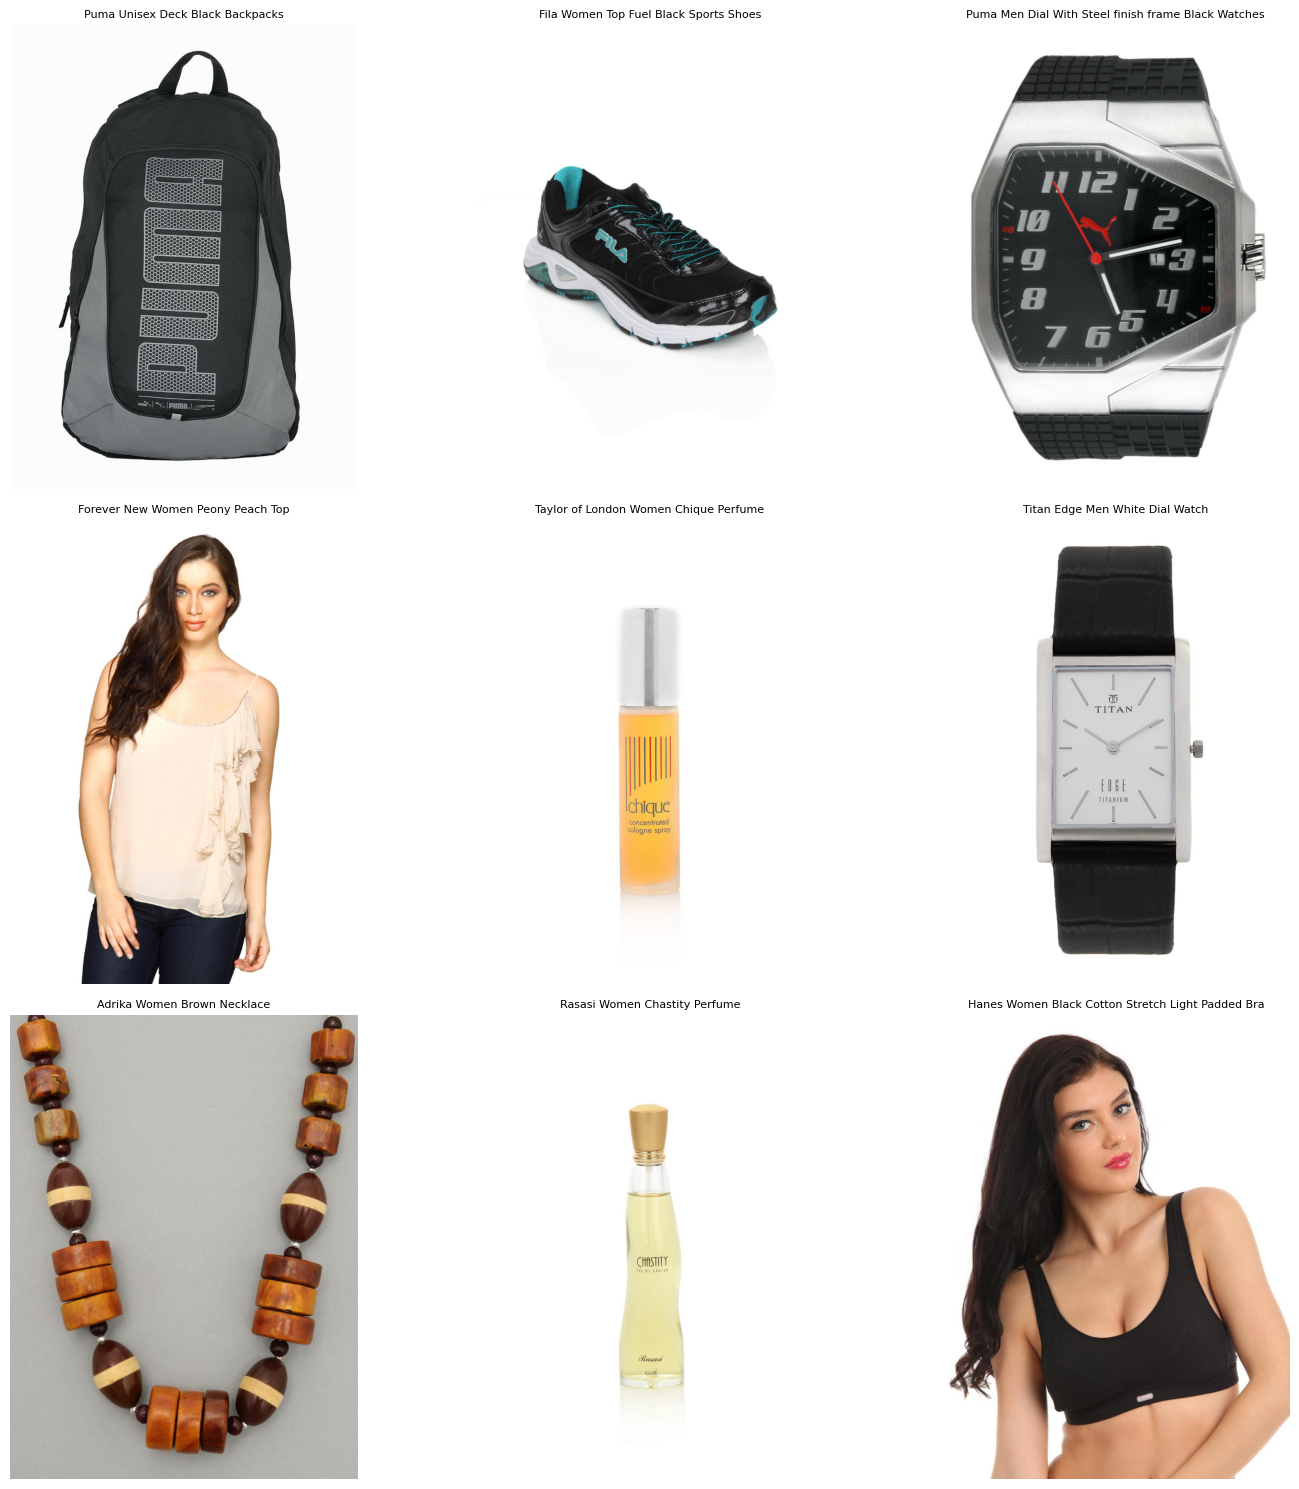

In [10]:

IMAGE_COL = "image"   
TEXT_COL = "display name"  

df["image_path"] = df[IMAGE_COL].apply(lambda x: os.path.join(IMAGES_DIR, str(x)))
df["file_exists"] = df["image_path"].apply(os.path.exists)
df_vis = df[df["file_exists"] == True].dropna(subset=[TEXT_COL])

sample_df = df_vis.sample(9, random_state=42)
plt.figure(figsize=(15, 15))
for i, (_, row) in enumerate(sample_df.iterrows(), 1):
    try:
        img = Image.open(row["image_path"]).convert("RGB")
        plt.subplot(3, 3, i)
        plt.imshow(img)
        plt.title(str(row[TEXT_COL])[:60], fontsize=8)
        plt.axis("off")
    except Exception as e:
        print(f"Ошибка при загрузке {row['image_path']}: {e}")
    
plt.tight_layout()
plt.show()


> #### Результат анализа соответствия картинок тексту: 
- *__соответствуют__*.

### Cмотрим разрешение картинок

In [11]:

sample_paths = df_vis["image_path"].sample(10).tolist()
for img_path in sample_paths:
    try:
        with Image.open(img_path) as img:
            print(f"{os.path.basename(img_path)} -> {img.size}")
    except Exception as e:
        print(f"Ошибка в файле {img_path}: {e}")
        

49089.jpg -> (1080, 1440)
30029.jpg -> (1080, 1440)
39370.jpg -> (1080, 1440)
28584.jpg -> (1080, 1440)
22680.jpg -> (1080, 1440)
28633.jpg -> (1080, 1440)
26103.jpg -> (1080, 1440)
33468.jpg -> (1080, 1440)
7674.jpg -> (1080, 1440)
43005.jpg -> (1080, 1440)


> разрешение всех картинок стандартное (1080x1440)

### Считаем пропуски и дубликаты, и удаляем их

In [12]:

print(f"Размер до очистки: {df.shape}")

print("\nИнформация о пропусках:\n")
missing_info = pd.DataFrame({
    "Пропуски": df.isna().sum(),
    "Процент (%)": (df.isna().mean() * 100).round(2)
})
print(missing_info)

df_clean = df.dropna().drop_duplicates()
print(f"\nРазмер после очистки: {df_clean.shape}\n")
print(f"Оставшиеся пропуски:\n{df_clean.isna().sum()}\n")
print(f"Оставшиеся дубликаты: {df_clean.duplicated().sum()}")


Размер до очистки: (44441, 6)

Информация о пропусках:

              Пропуски  Процент (%)
image                0         0.00
description        281         0.63
display name         7         0.02
category             0         0.00
image_path           0         0.00
file_exists          0         0.00

Размер после очистки: (44160, 6)

Оставшиеся пропуски:
image           0
description     0
display name    0
category        0
image_path      0
file_exists     0
dtype: int64

Оставшиеся дубликаты: 0


### Делим на train и test

In [13]:

train_df, test_df = train_test_split(
    df_clean,
    test_size=0.1,
    random_state=42,
    shuffle=True
)

print("Тренировочные:", train_df.shape)
print("Тестовые:", test_df.shape)


Тренировочные: (39744, 6)
Тестовые: (4416, 6)


### Класс датасета

In [14]:

class ImageTextDataset(Dataset):
    def __init__(self, dataframe, image_dir, image_clmn, text_clmn):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.image_clmn = image_clmn
        self.text_clmn = text_clmn
        
    def __len__(self):
        return len(self.dataframe)
        
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_path = os.path.join(self.image_dir, str(row[self.image_clmn]))
        
        image = Image.open(image_path).convert("RGB")
        text = row[self.text_clmn]
            
        return image, text
        

In [15]:

dataset = ImageTextDataset(
    dataframe=df_clean,
    image_dir=IMAGES_DIR,
    image_clmn=IMAGE_COL,
    text_clmn=TEXT_COL
)
 

> ## Выводы по разделу:
> - Успешно загружен датасет fashion-product-text-images-dataset. 
> - Загружено 44443 файлов, общий объем: 3.91 GB.
> - После удаления дубликатов и строк с пропусками, финальный размер выборки составил 44160 записей.
> - Визуальный анализ показал соответствие между изображениями товаров и их текстовым описанием.
> - Данные были разделены на обучающие (39744 записи) и тестовые (4416 записей) в пропорции 90/10 для последующего обучения и валидации модели.

## Работа с моделью

> #### Определим устройство на котором будем считать

In [16]:

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
    
print(f"Устройство: {device}")


Устройство: mps


> #### Подгружаем токен из .env

In [17]:

if load_dotenv():
    print("Переменные из .env загружены")

if os.getenv("HF_TOKEN"):
    print("HF_TOKEN обнаружен")
else:
    print("HF_TOKEN не обнаружен. Возможны ограничения по скорости загрузки")
    

Переменные из .env загружены
HF_TOKEN обнаружен


### Загружаем модель

In [18]:

model_name = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_name).to(device)
processor = CLIPProcessor.from_pretrained(model_name)


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Прогоним через модель несколько примеров из датасета и узнаем CLIP-скоры.

In [19]:

def get_clip_score(image, text):
    inputs = processor(
        text=[text],
        images=image,
        return_tensors="pt",
        padding=True
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
        score = torch.nn.functional.cosine_similarity(
            outputs.image_embeds, outputs.text_embeds
        ).item()
    return score
    
for i in range(5):
    image, text = dataset[i]
    score = get_clip_score(image, text)
    print(f"Пример {i+1}")
    print("Текст:", text)
    print("CLIP-score:", round(score, 4))
    print("-" * 40)
    

Пример 1
Текст: Puma Men Black 65CC Lo Ducati Sports Shoes
CLIP-score: 0.3197
----------------------------------------
Пример 2
Текст: Nike Men Charcoal Grey Shorts
CLIP-score: 0.3068
----------------------------------------
Пример 3
Текст: Kiara Women Teal Handbag
CLIP-score: 0.3289
----------------------------------------
Пример 4
Текст: Fastrack Women Freestyle Sports Analog Steel Black Watch
CLIP-score: 0.3091
----------------------------------------
Пример 5
Текст: ID Men Brown Casual Shoes
CLIP-score: 0.3317
----------------------------------------


> ## Выводы по разделу:
> - Для работы выбрана предобученная модель openai/clip-vit-base-patch32.
> - Первичное тестирование модели на примерах из датасета показало значения CLIP-score в районе 0.30-0.33. Эти значения подтверждают, что модель корректно сопоставляет общие признаки товаров.

# Дообучение

In [20]:

class CLIPDataset(Dataset):
    def __init__(self, df, processor, is_train=True):
        self.df = df.reset_index(drop=True)
        self.processor = processor
        self.is_train = is_train
        
    def __len__(self):
        return len(self.df)
        
    def apply_augmentations(self, image):
        if not self.is_train:
            return image
        
        if random.random() > 0.5:
            image = image.transpose(Image.FLIP_LEFT_RIGHT)
        
        if random.random() > 0.7:
            image = image.rotate(random.uniform(-10, 10))
            
        return image
        
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['image_path']).convert("RGB")
        
        image = self.apply_augmentations(image)
        
        text = row['display name']
        inputs = self.processor(
            text=[text],
            images=image,
            return_tensors="pt",
            padding="max_length",
            max_length=77,
            truncation=True
        )
        
        item = {k: v.squeeze(0) for k, v in inputs.items()}
        return item
        

## Создаем загрузчики

In [21]:

train_dataset = CLIPDataset(train_df, processor, is_train=True)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = CLIPDataset(test_df, processor, is_train=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


### Функция потерь

In [22]:

def contrastive_loss(logits_per_image, logits_per_text):
    device = logits_per_image.device
    labels = torch.arange(logits_per_image.size(0), device=device)
    
    loss_img = torch.nn.functional.cross_entropy(logits_per_image, labels)
    loss_txt = torch.nn.functional.cross_entropy(logits_per_text, labels)
    
    return (loss_img + loss_txt) / 2
    

### Расчет среднего CLIP-score

In [23]:

def evaluate_baseline(loader, model, processor, device):
    scores = []
    model.eval()
    with torch.no_grad():
        for batch in tqdm(loader):
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            score = torch.nn.functional.cosine_similarity(
                outputs.image_embeds, outputs.text_embeds
            ).mean().item()
            scores.append(score)
    return sum(scores) / len(scores)
    
print(f"Средний CLIP-score до дообучения: {evaluate_baseline(test_loader, model, processor, device):.4f}")


100%|███████████████████████████████████████████████████████████████████████████████████| 35/35 [01:24<00:00,  2.41s/it]

Средний CLIP-score до дообучения: 0.3163


### Цикл обучения и валидации

In [23]:

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.1)
num_epochs = 8

history = {
    "train_loss": [],
    "train_clip_score": [],
    "val_loss": [],
    "val_clip_score": [],
    "logit_scale": []
}

for epoch in range(num_epochs):
    model.train()
    
    train_loss_accum = 0
    train_score_accum = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    
    for batch in pbar:
        optimizer.zero_grad()
        batch = {k: v.to(device) for k, v in batch.items()}
        
        outputs = model(**batch)
        
        logits_per_image = outputs.logits_per_image
        logits_per_text = outputs.logits_per_text
        
        current_scale = model.logit_scale.exp().item()
        
        loss = contrastive_loss(logits_per_image, logits_per_text)
        loss.backward()
        optimizer.step()
        
        with torch.no_grad():
            score = torch.nn.functional.cosine_similarity(
                outputs.image_embeds, outputs.text_embeds
            ).mean().item()
            
        train_loss_accum += loss.item()
        train_score_accum += score
        
        pbar.set_postfix({
            "loss": f"{loss.item():.4f}", 
            "score": f"{score:.4f}",
            "scale": f"{current_scale:.2f}"
        })
    
    avg_train_loss = train_loss_accum / len(train_loader)
    avg_train_score = train_score_accum / len(train_loader)
    
    model.eval()
    val_loss_accum = 0
    val_score_accum = 0
    
    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            
            v_loss = contrastive_loss(outputs.logits_per_image, outputs.logits_per_text)
            val_loss_accum += v_loss.item()
            
            v_score = torch.nn.functional.cosine_similarity(
                outputs.image_embeds, outputs.text_embeds
            ).mean().item()
            val_score_accum += v_score
            
    avg_val_loss = val_loss_accum / len(test_loader)
    avg_val_score = val_score_accum / len(test_loader)
    
    history["train_loss"].append(avg_train_loss)
    history["train_clip_score"].append(avg_train_score)
    history["val_loss"].append(avg_val_loss)
    history["val_clip_score"].append(avg_val_score)
    history["logit_scale"].append(current_scale)
    
    print("-" * 50)
    print(f"Итоги эпохи {epoch+1}:")
    print(f"Обучение:  Loss = {avg_train_loss:.4f}, CLIP Score = {avg_train_score:.4f}")
    print(f"Валидация: Loss = {avg_val_loss:.4f}, CLIP Score = {avg_val_score:.4f}")
    print(f"Температура: {current_scale:.2f}")    
    torch.save(model.state_dict(), f"clip_model_epoch_{epoch+1}.pt")
    print("-" * 50)
    

Epoch 1/8 [Train]: 100%|██████████████████████| 311/311 [16:40<00:00,  3.22s/it, loss=0.1048, score=0.3197, scale=99.82]


--------------------------------------------------
Итоги эпохи 1:
Обучение:  Loss = 0.5140, CLIP Score = 0.3128
Валидация: Loss = 0.3946, CLIP Score = 0.3201
Температура: 99.82
--------------------------------------------------


Epoch 2/8 [Train]: 100%|██████████████████████| 311/311 [17:55<00:00,  3.46s/it, loss=0.2817, score=0.3238, scale=99.66]


--------------------------------------------------
Итоги эпохи 2:
Обучение:  Loss = 0.2897, CLIP Score = 0.3252
Валидация: Loss = 0.3545, CLIP Score = 0.3202
Температура: 99.66
--------------------------------------------------


Epoch 3/8 [Train]: 100%|██████████████████████| 311/311 [17:30<00:00,  3.38s/it, loss=0.1054, score=0.3274, scale=99.51]


...

--------------------------------------------------
Итоги эпохи 6:
Обучение:  Loss = 0.1213, CLIP Score = 0.3444
Валидация: Loss = 0.2886, CLIP Score = 0.3375
Температура: 99.06
--------------------------------------------------


Epoch 7/8 [Train]: 100%|██████████████████████| 311/311 [17:12<00:00,  3.32s/it, loss=0.0112, score=0.3488, scale=98.91]


--------------------------------------------------
Итоги эпохи 7:
Обучение:  Loss = 0.1116, CLIP Score = 0.3485
Валидация: Loss = 0.2847, CLIP Score = 0.3407
Температура: 98.91
--------------------------------------------------


Epoch 8/8 [Train]: 100%|██████████████████████| 311/311 [17:14<00:00,  3.32s/it, loss=0.0618, score=0.3487, scale=98.75]


--------------------------------------------------
Итоги эпохи 8:
Обучение:  Loss = 0.1015, CLIP Score = 0.3509
Валидация: Loss = 0.2734, CLIP Score = 0.3394
Температура: 98.75
--------------------------------------------------


### Визуализация результатов

#### График функции потерь

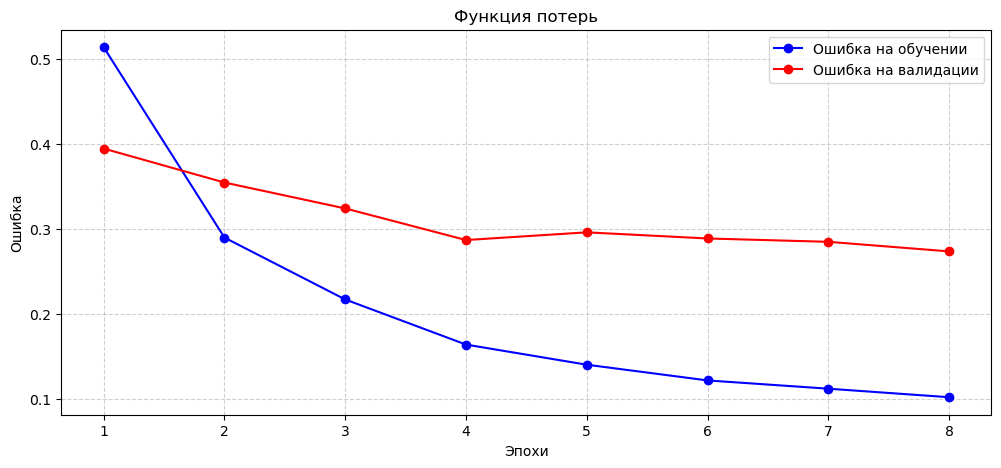

In [24]:

epochs = range(1, num_epochs + 1)
plt.figure(figsize=(12, 5))

plt.plot(epochs, history["train_loss"], 'bo-', label='Ошибка на обучении')
plt.plot(epochs, history["val_loss"], 'ro-', label='Ошибка на валидации')
plt.title('Функция потерь')
plt.xlabel('Эпохи')
plt.ylabel('Ошибка')
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()


#### График CLIP Score

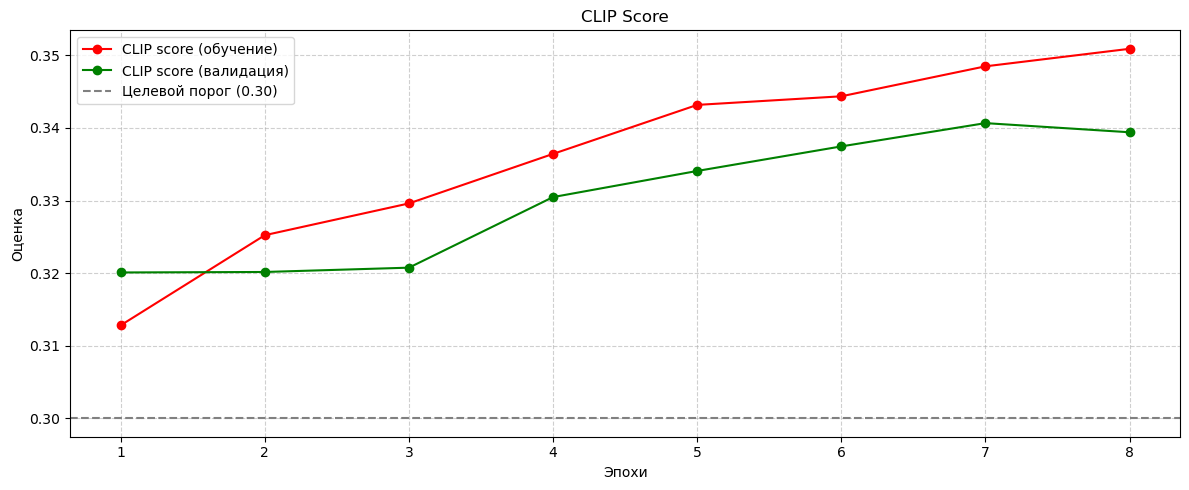

In [25]:

plt.figure(figsize=(12, 5))
plt.plot(epochs, history["train_clip_score"], 'ro-', label='CLIP score (обучение)')
plt.plot(epochs, history["val_clip_score"], 'go-', label='CLIP score (валидация)')
plt.axhline(y=0.30, color='gray', linestyle='--', label='Целевой порог (0.30)')
plt.title('CLIP Score')
plt.xlabel('Эпохи')
plt.ylabel('Оценка')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


> ## Выводы и результаты:
> - Процесс дообучения проводился в течение 8 эпох с использованием функции потерь.
> - Динамика обучения показывает стабильное снижение значения функции потерь с 0.3946 до 0.2734. Валидационное значение функции потерь падает синхронно с обучающим, это значит, что модель не просто запомнила картинки из обучения, а научилась находить общие принципы.
> - Значение метрики CLIP-score на валидационной выборке показало уверенный рост с 0.3201 до 0.3407 на 7й эпохе, на 8й эпохе значение CLIP-score незначительно опустилось до 0.3394, видимо произошло легкое переобучение. Для реализации поиска будем использовать чекпоинт 7й эпохи, ведь чекпоинты каждой эпохи сохранены.
> - Температура плавно снижается с 99.82 до 98.75. Это говорит о том, что модель переходит от грубого поиска к более точному.

> ## Анализ эффективности дообучения:
> 
> - Перед началом дообучения расчитано среднее CLIP-score на всей тестовой выборке, значение равно 0.3163.
> - В процессе дообучения метрика стабильно росла и достигла пика 0.3407 на 7й эпохе.
> - Итоговый прирост метрики составил ~8%. Это подтверждает, что дообучение помогло модели лучше адаптироваться к специфике датасета одежды, что повысило точность сопоставления текста и изображения по сравнению со стандартной моделью.

# Реализация системы поиска товаров

## Работа с данными

### Переводим модель в режим оценки

> __Так как на 7й эпохе было самое большое значение CLIP-score загрузим веса модели из 7го чекпоинта.__

In [33]:

checkpoint_7 = "clip_model_epoch_7.pt"
model.load_state_dict(torch.load(checkpoint_7, map_location=device))
print(f"Веса модели заменены на чекпоинт: {checkpoint_7}")


Веса модели заменены на чекпоинт: clip_model_epoch_7.pt


In [34]:

model.eval()


CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,),

### Создаем DataLoader

In [35]:

full_dataset = ImageTextDataset(
    dataframe=df_clean, 
    image_dir=IMAGES_DIR,
    image_clmn=IMAGE_COL,
    text_clmn=TEXT_COL
)

def collate_fn(batch):
    images = [item[0] for item in batch]
    texts = [item[1] for item in batch]
    inputs = processor(images=images, text=texts, return_tensors="pt", padding=True)
    return inputs
    
full_loader = torch.utils.data.DataLoader(
    full_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=collate_fn
)


### Проходим по всему датасету

In [36]:

all_image_embeds = []
print("Начинаем расчет векторов для всех изображений...")

with torch.no_grad():
    for batch in tqdm(full_loader):
        inputs = {k: v.to(device) for k, v in batch.items()}
        outputs = model.get_image_features(pixel_values=inputs['pixel_values'])
        
        if hasattr(outputs, 'pooler_output'):
            image_outputs = outputs.pooler_output
        else:
            image_outputs = outputs
            
        image_outputs = image_outputs / image_outputs.norm(p=2, dim=-1, keepdim=True)
        
        all_image_embeds.append(image_outputs)
        

Начинаем расчет векторов для всех изображений...


100%|█████████████████████████████████████████████████████████████████████████████████| 345/345 [06:46<00:00,  1.18s/it]


### Объединяем все батчи в один большой тензор и сохраняем

In [37]:

if isinstance(all_image_embeds, list):
    all_image_embeds = torch.cat(all_image_embeds, dim=0)
    
print(f"Получена матрица эмбеддингов размером: {all_image_embeds.shape}")

all_image_embeds = all_image_embeds.to(device)
all_image_embeds = all_image_embeds / all_image_embeds.norm(p=2, dim=-1, keepdim=True)
print("Матрица эмбеддингов перенесена на устройство и нормализована.")

torch.save({
    'embeddings': all_image_embeds,
    'image_paths': df_clean['image_path'].tolist(),
    'descriptions': df_clean[TEXT_COL].tolist()
}, 'fashion_search_index.pt')

print("Индекс для поиска сохранен в fashion_search_index.pt")


Получена матрица эмбеддингов размером: torch.Size([44160, 512])
Матрица эмбеддингов перенесена на устройство и нормализована.
Индекс для поиска сохранен в fashion_search_index.pt


## Функция поиска товаров

In [38]:

def search_fashion_items(model, processor, query_text, image_embeddings, df, top_k=5, device="cpu"):
    model.eval()
    
    with torch.no_grad():
        inputs = processor(text=[query_text], return_tensors="pt", padding=True).to(device)
        outputs = model.get_text_features(**inputs)
        
        if hasattr(outputs, 'pooler_output'):
            text_features = outputs.pooler_output
        else:
            text_features = outputs
            
        text_features = text_features / text_features.norm(p=2, dim=-1, keepdim=True)
    
    if isinstance(image_embeddings, list):
        image_embeddings = torch.cat(image_embeddings)
        
    similarities = (text_features @ image_embeddings.T).squeeze(0)
    
    values, indices = torch.topk(similarities, k=top_k)
    
    plt.figure(figsize=(20, 5))
    print(f"Результаты по запросу: '{query_text}'")
    
    for i, idx in enumerate(indices):
        idx = idx.item()
        img_path = df.iloc[idx]['image_path']
        display_name = df.iloc[idx]['display name']
        score = values[i].item()
        
        plt.subplot(1, top_k, i + 1)
        try:
            img = Image.open(img_path)
            plt.imshow(img)
            plt.title(f"{display_name}\nScore: {score:.3f}", fontsize=10)
        except Exception as e:
            plt.title("Ошибка загрузки фото")
        plt.axis('off')
    
    plt.show()
    

### Тестируем написанную функцию

> #### вариант 1

Результаты по запросу: 'stylish black leather bag for women'


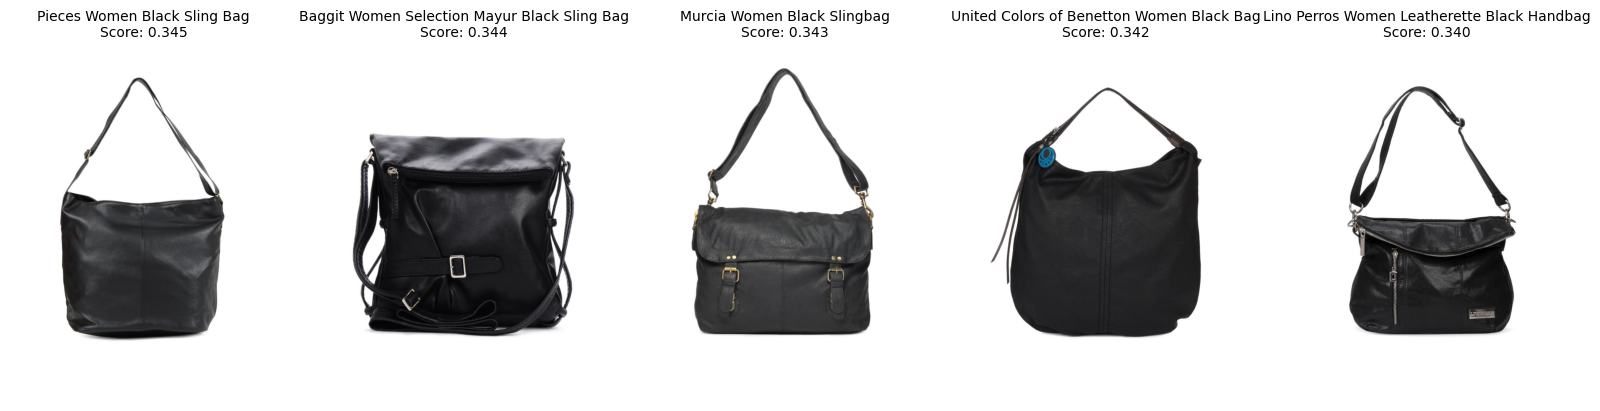

Результаты по запросу: 'red skirt'


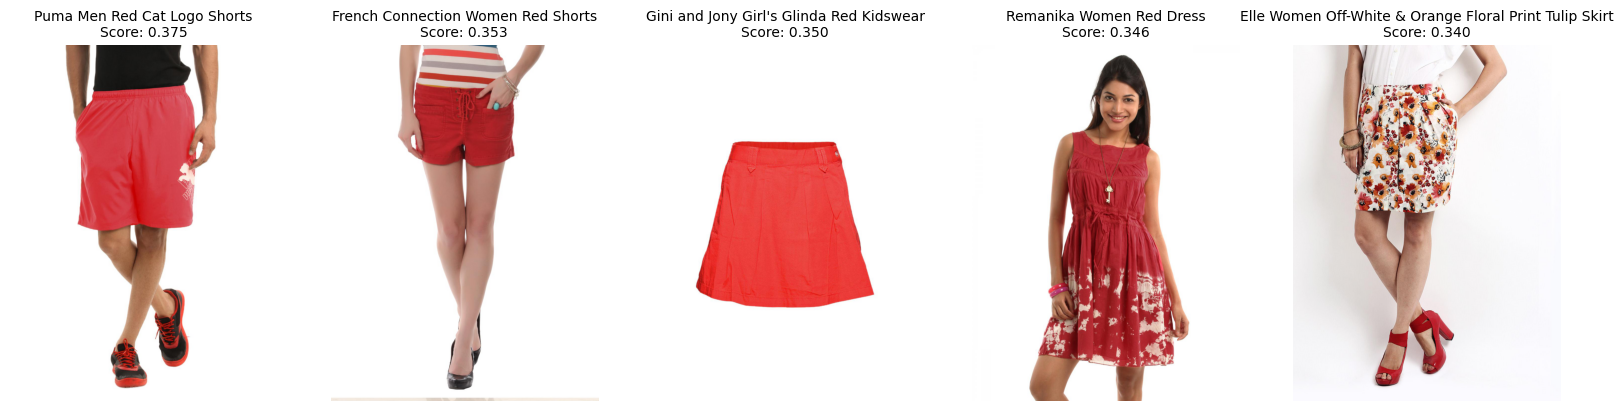

Результаты по запросу: 'blue sunglasses'


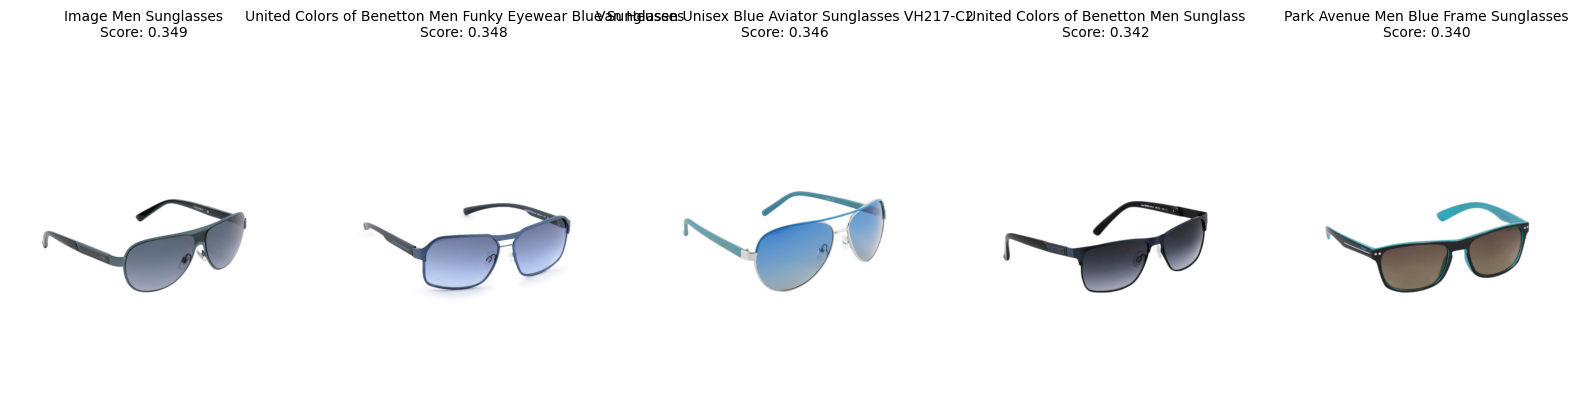

Результаты по запросу: 'mickey mouse'


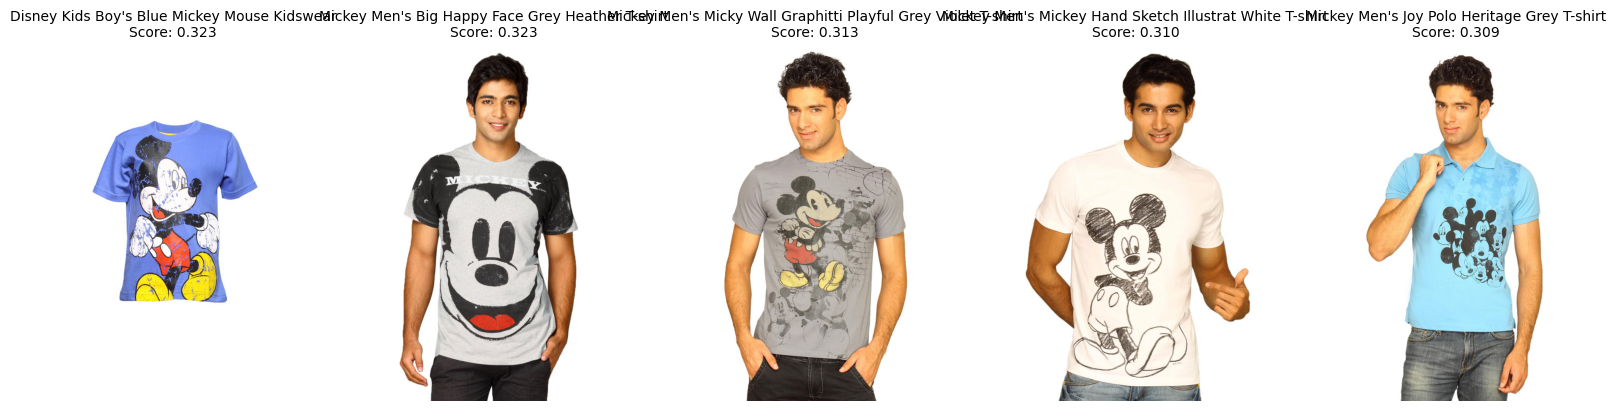

Результаты по запросу: 'yellow'


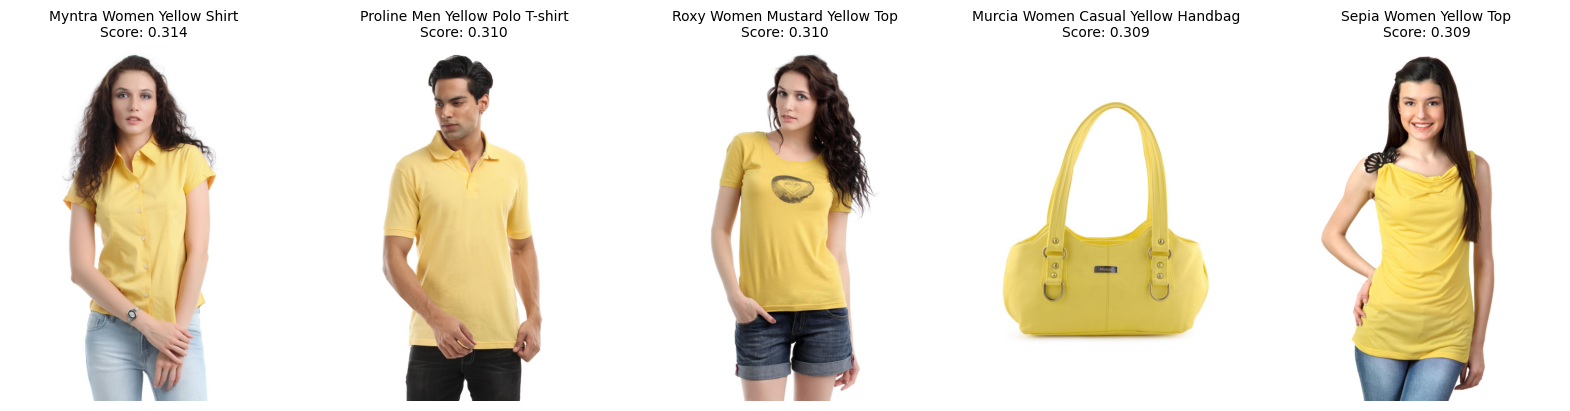

In [39]:

test_queries = [
    "stylish black leather bag for women",
    "red skirt",
    "blue sunglasses",
    "mickey mouse",
    "yellow",
]

for q in test_queries:
    search_fashion_items(
        model=model,
        processor=processor,
        query_text=q,
        image_embeddings=all_image_embeds,
        df=df_clean,
        top_k=5,
        device=device
    )


> #### вариант 2

In [40]:

from ipywidgets import interact, widgets

query_input = widgets.Text(
    value='stylish black leather bag for women', 
    placeholder='Например: red skirt',          
    description='Введите запрос:',               
    style={'description_width': 'initial'} 
)
@interact(query_text=query_input)
def simple_search(query_text):
 
    if not query_text.strip():
        print("Пожалуйста, введите поисковый запрос.")
        return
        
    search_fashion_items(
        model=model,
        processor=processor,
        query_text=query_text,
        image_embeddings=all_image_embeds,
        df=df_clean,
        top_k=5,
        device=device
    )
    

interactive(children=(Text(value='stylish black leather bag for women', description='Введите запрос:', placeho…

> ### Пример результата работы поиска "вариант 2".

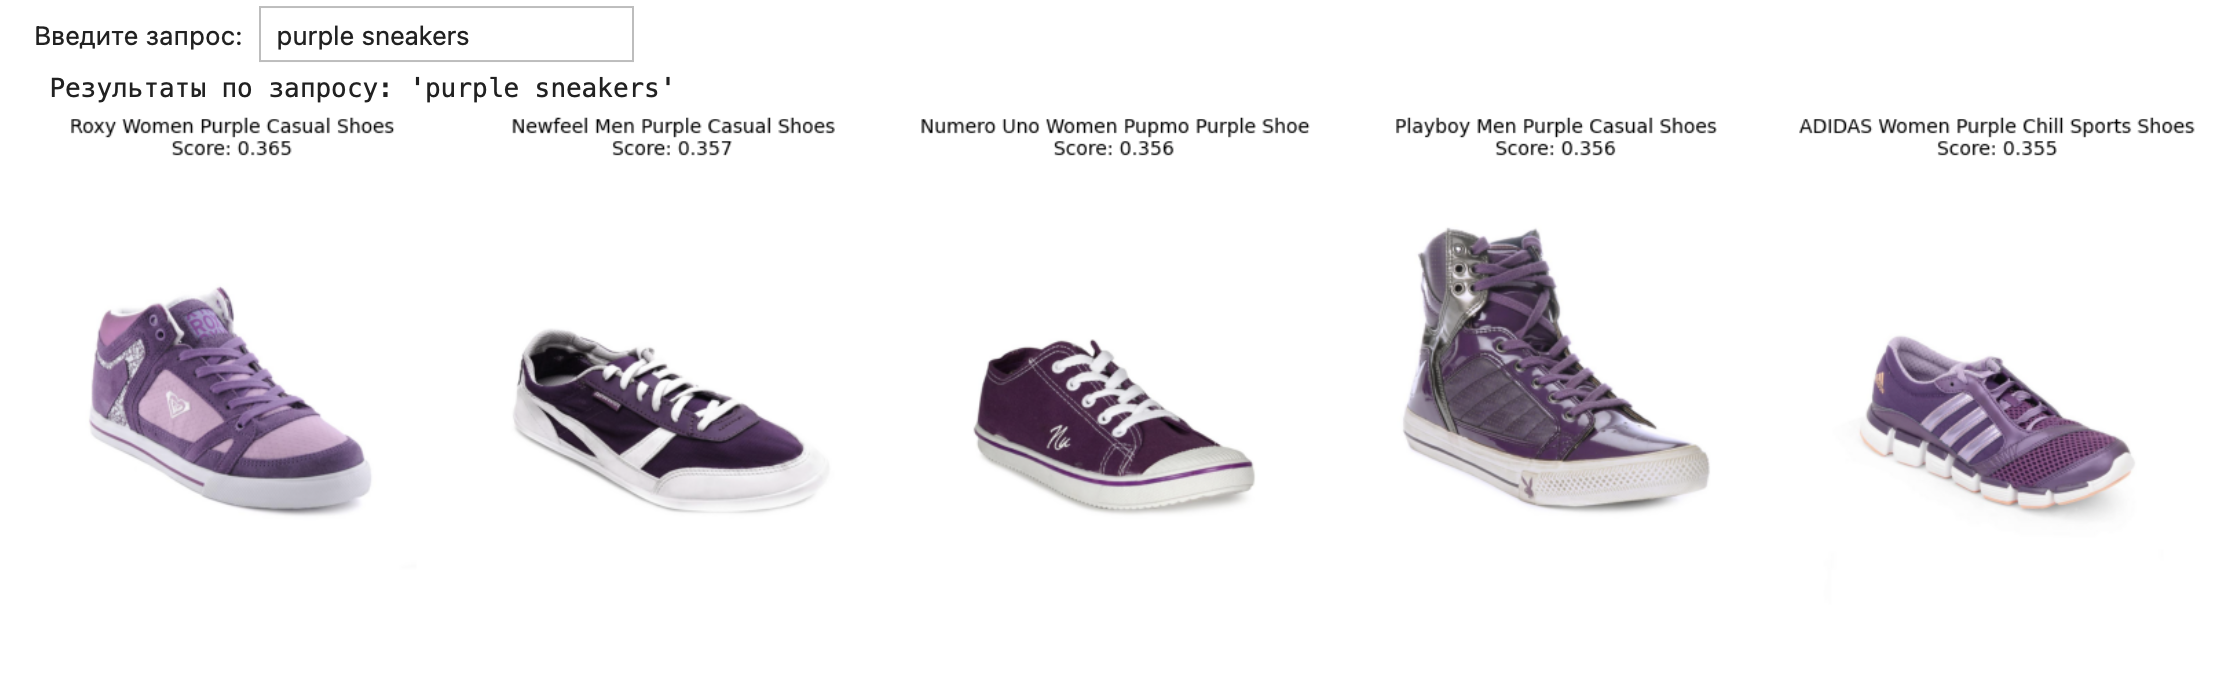

> ## Выводы по разделу:
> - На основе дообученной модели реализован прототип поисковой системы по текстовому запросу.
> - Сформирована матрица эмбеддингов для всего каталога изображений. Использование векторных операций позволяет находить 5 наиболее подходящих товаров практически мгновенно.
> - Тестирование на запросах, например, "stylish black leather bag for women", показало хорошую релевантность, позиции выдачи соответствуют запросу не только по категории, но и, например, по цвету. Однако в случае с красной юбкой система выдала и шорты, очень похожие на юбку, и красное платье, почти юбка, и юбку которая не совсем красная. Скорее всего это происходит потому, что CLIP семантическая модель, и для неё шорты и юбка семантически близки.